# Figure5: plotting and resource-data code

This notebook contains the original figure-production cells. Inputs are under `data/Figure5/`; outputs may be written to `output/`.

## Resource-data sheets included for this figure

- `fig5a-expand_in_subtype-delta_delta-stat` — resource-data sheet for the corresponding panel.
- `fig5a-expand_in_subtype-post_pre_delta` — resource-data sheet for the corresponding panel.
- `fig5b-diversity-cd8_cx3cr1-min10` — resource-data sheet for the corresponding panel.
- `fig5b-expand_pct-cd8_cx3cr1-min10` — resource-data sheet for the corresponding panel.
- `fig5c-cyto_exhau_score-cell_state` — resource-data sheet for the corresponding panel.

The final resource tables use `NR` as the non-responder label. The original analysis cells are retained so that their complete plotting logic is traceable.

In [21]:
# Harmonize standalone response labels at input time: PR -> NR.
harmonize_nr_labels <- function(x) {
  normalize_df <- function(df) {
    for (nm in names(df)) {
      if (is.character(df[[nm]]) || is.factor(df[[nm]])) {
        df[[nm]] <- gsub("\bPR\b", "NR", as.character(df[[nm]]), perl = TRUE)
      }
    }
    df
  }
  if (is.data.frame(x)) return(normalize_df(x))
  if (isS4(x) && "meta.data" %in% slotNames(x)) {
    x@meta.data <- normalize_df(x@meta.data)
  }
  x
}


# Figure 5 plotting code\n\nOrganized copy of the manuscript plotting notebook. This standalone notebook runs from `code/`; inputs are in `../data/` and outputs are written to `../output/`. Large inputs are relative symbolic links, described in `../../data/DATA_INPUT_MANIFEST.tsv`.\n

# figure 5 vlz

- kernel: r_env, R 4.1.3
- date: 2024-02-05
- desc: part of fig4-new & fig4

## load

In [22]:
library(tidyverse)
if (requireNamespace("logging", quietly = TRUE)) { library(logging); logging::basicConfig() } else { loginfo <- function(...) invisible(NULL) }
library(ggpubr)
library(ggsci)
library(patchwork)

source('shared/r_funcs.r')

theme_set(theme_pubr())

options(warn = -1)

outdir <- "../output"
create_dir(outdir)

In [23]:
f_pat_gp <- '../data/Figure5/tables/patient_info_v2.tsv'
gp <- 'response'
gp_lvls$response <- c('R', 'NR')
gp_comp_map$response <- list(
  c('R-pre', 'R-post'),
  c('NR-pre', 'NR-post'),
  c('R-pre', 'NR-pre'),
  c('R-post', 'NR-post')
)
gp_comp_diff_map$response <- list(c('R', 'NR'))
gp_comp_map_pre$response <- list(c('R-pre', 'NR-pre'))
comb_order <- c('R-pre', 'R-post', 'NR-pre', 'NR-post')

In [24]:
celltype_map <- list(
    'T_MKI67' = c('T_Prolif')
)

cell_state_map <- list(
    'cytotoxic' = c('CD8_ANXA1', 'CD8_CCL5', 'CD8_CX3CR1', 'CD8_FOS', 'CD8_GZMK', 'CD8_KLRB1'),
    'exhausted' = c('CD4_CXCL13', 'CD8_CXCL13', 'CD8_TYMS', 'T_MKI67', 'Treg_TNFRSF4'),
    'dying' = c('T_Mito'),
    'others' = c('CD4_KLRB1', 'CD8_CD74', 'CD8_IFIT1', 'T_IL7R', 'T_Ribo', 'Treg_LTB')
)
cell_state_order <- c('cytotoxic', 'exhausted', 'dying', 'others')
cell_state_color <- c('exhausted' = '#023fa5', 'cytotoxic' = 'red', 
                      'dying' = '#bb7784', 'others' = '#ff9639')

## 5a: pseudo forest plot

### functions

In [25]:
cal_stat <- function(x, y) {
    t_obj <- t.test(x = x, y = y)
    res <- data.frame(
        mean_diff = t_obj$estimate[1] - t_obj$estimate[2],
        conf_int_upper = t_obj$conf.int[2],
        conf_int_lower = t_obj$conf.int[1],
        stderr = t_obj$stderr,
        pval = t_obj$p.value
    )
    return(res)
}

### expansion

no NK cells, paird patients, delta (good-poor) of post-pre delta expand in subtype

In [26]:
f_expand_diff <- '../data/Figure5/stage4/a03_tcr/expansion/diff_expandPct_min10.csv'

# post-pre delta
df_delta <- read_csv(f_expand_diff, show_col_types = F) %>% 
    filter(!grepl('^NK', subtype)) %>%
    select(patient, subtype, Baseline, Treat, pct_expand_diff) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient')

for (nm in names(celltype_map)) {
    df_delta$subtype[df_delta$subtype %in% celltype_map[[nm]]] <- nm
}
loginfo('%g records, %g patients, %g celltypes', nrow(df_delta), length(unique(df_delta$patient)), length(unique(df_delta$subtype)))

2026-07-17 22:49:31.093715 INFO::411 records, 28 patients, 18 celltypes


In [27]:
df_delta %>% write_tsv(str_glue('{outdir}/fig5a-expand_in_subtype-post_pre_delta.tsv'))

In [28]:
# cal stat by subtype
res <- do.call(rbind.data.frame, lapply(X = unique(df_delta$subtype), FUN = function(ctype) {
    cal_stat(x = filter(df_delta, subtype == ctype, .data[[gp]] == 'R') %>% pull(pct_expand_diff),
             y = filter(df_delta, subtype == ctype, .data[[gp]] == 'NR') %>% pull(pct_expand_diff)) %>%
    mutate(subtype = ctype)
}))
# add cell state info
res$cell_state <- 'others'
for (nm in names(cell_state_map)){
    res$cell_state[res$subtype %in% cell_state_map[[nm]]] <- nm
}
loginfo('%g records, %g celltypes', nrow(res), length(unique(res$subtype)))
res %>% write_tsv(str_glue('{outdir}/fig5a-expand_in_subtype-delta_delta-stat.tsv'))

2026-07-17 22:49:31.748382 INFO::18 records, 18 celltypes


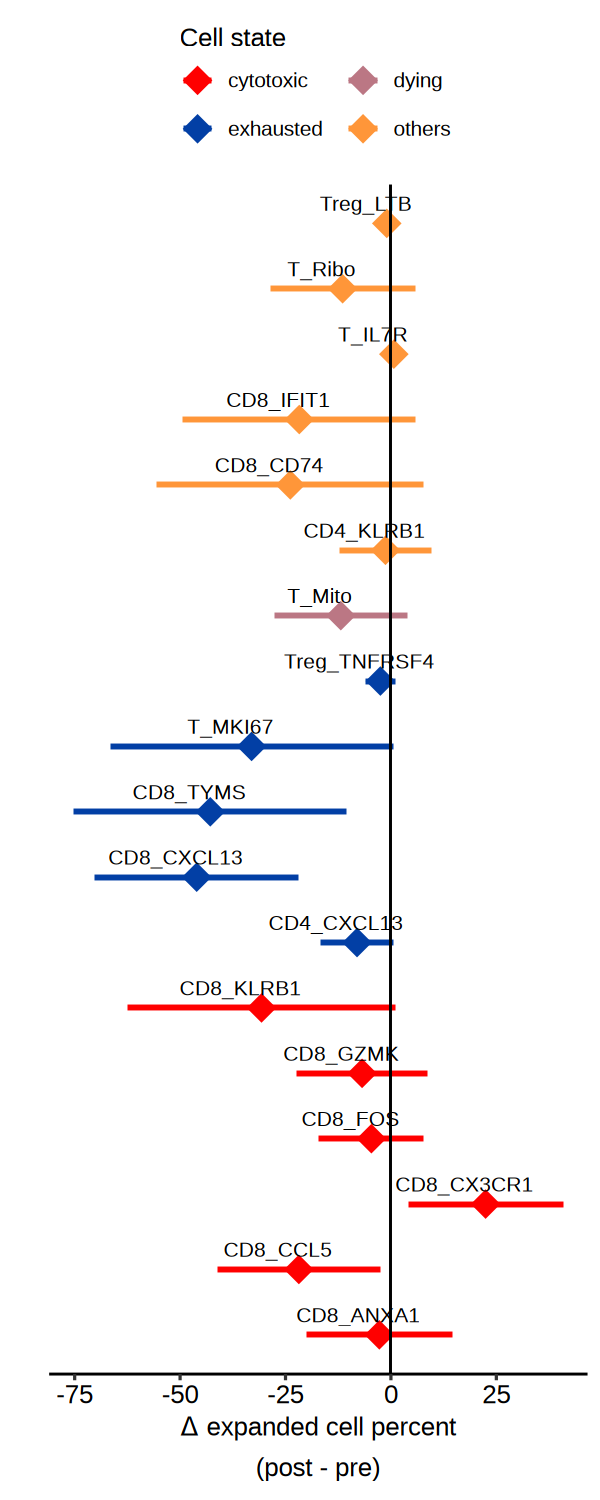

In [29]:
p <- read_tsv(str_glue('{outdir}/fig5a-expand_in_subtype-delta_delta-stat.tsv'), show_col_types = F) %>%
    mutate(subtype = factor(subtype, levels = unlist(cell_state_map)), 
           cell_state = factor(cell_state, levels = names(cell_state_map))) %>%
    ggplot(aes(x = mean_diff, y = subtype, color = cell_state, label = subtype)) +
        geom_pointrange(aes(xmin = conf_int_lower, xmax = conf_int_upper), linewidth = 1, size = 1.5, shape = 18) +
        geom_vline(xintercept = 0, color = 'black') +
        geom_text(color = 'black', size = 3.5, nudge_x = -5, nudge_y = 0.3) +
        scale_color_manual(values = cell_state_color) +
        guides(color = guide_legend(ncol = 2, title.position = 'top')) +
        labs(x = bquote(atop(Delta~'expanded cell percent', '(post - pre)')), y = '', color = 'Cell state') + 
        theme(axis.line.y = element_blank(), axis.text.y = element_blank(), axis.ticks.y = element_blank())
ggsave(filename = str_glue('{outdir}/fig5a-pseudo_forest-expand_in_subtype-delta_delta.pdf'), plot = p, width = 2.5, height = 7)
# 在当前 notebook 中显示最后生成的图。
options(repr.plot.width = 4, repr.plot.height = 10, repr.plot.res = 150)
p


## 5b: boxplot for CD8_CX3CR1

- diversity, diff of expand, expansion percent

In [30]:
f_expand <- '../data/Figure5/stage4/a03_tcr/expansion/expand_cell_pct.csv'
f_expand_diff <- '../data/Figure5/figures/fig5/fig5a-expand_in_subtype-post_pre_delta.tsv'  # this is based on min10 cells results
f_diversity <- '../data/Figure5/stage4/a03_tcr/diversity/shannon_way2_min10.csv'

min_cell_per_sample_subtype <- 10

### expand in cluster

In [31]:
# process
df <- read_csv(f_expand, show_col_types = F) %>%
    filter(subtype == 'CD8_CX3CR1') %>%
    filter(n_cell_per_sample_subtype >= min_cell_per_sample_subtype) %>%
    select(patient, sample_type, n_expand_cell_per_sample_stype, n_cell_per_sample_subtype,
           pct_in_cluster = pct_by_subtype, pct_in_sample = pct_by_sample) %>% 
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))
loginfo('%g samples for CD8_CX3CR1', nrow(df))
df %>% write_tsv(str_glue('{outdir}/fig5b-expand_pct-cd8_cx3cr1-min{min_cell_per_sample_subtype}.tsv'))

2026-07-17 22:49:34.851103 INFO::73 samples for CD8_CX3CR1


# A tibble: 1 × 13
  group1 group2 comparison_order paired    n1    n2 n_pairs statistic_W  p_raw
  <chr>  <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>  <dbl>
1 R-pre  R-post                1 FALSE     21    16      NA         103 0.0442
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


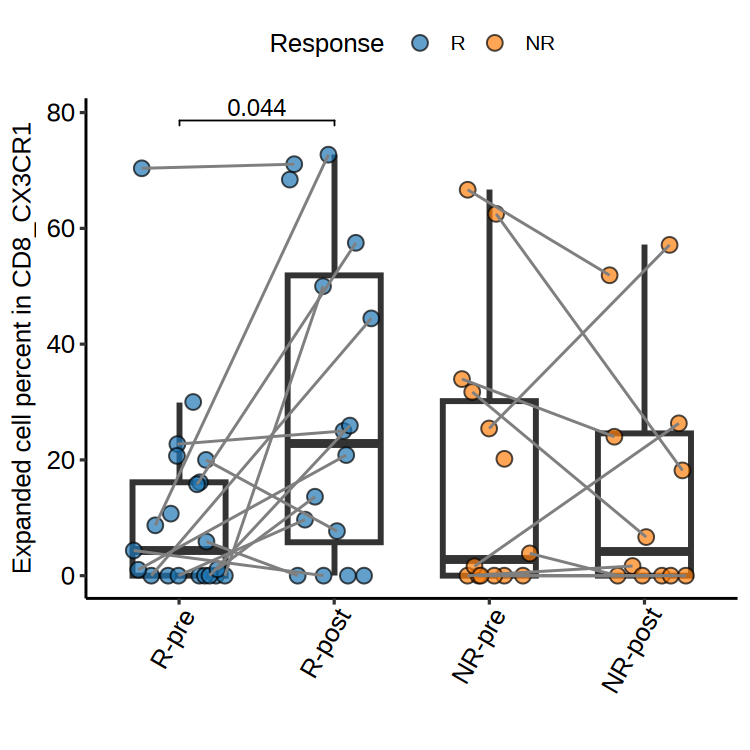

In [32]:
# Plot: compare pre versus post separately within R and NR.
fig5b_time_comparisons <- list(
    c('R-pre', 'R-post')
)

p <- read_tsv(
    str_glue('{outdir}/fig5b-expand_pct-cd8_cx3cr1-min{min_cell_per_sample_subtype}.tsv'),
    show_col_types = FALSE
) %>% 
    filter(!is.na(.data[[gp]])) %>% 
    cell_comp_boxplot(
        x = c(gp, 'sample_type'),
        y = 'pct_in_cluster',
        pt_fill = gp,
        facet_by = NULL,
        xorder = comb_order,
        fill_order = gp_lvls[[gp]],
        xangle = 60
    ) +
    labs(y = 'Expanded cell percent in CD8_CX3CR1', fill = 'Response')

p <- configure_panel_wilcox(
    p,
    x = 'plot_x',
    y = 'pct_in_cluster',
    comparisons = fig5b_time_comparisons,
    use_paired = FALSE,
    apply_correction = TRUE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)

ggsave(
    filename = str_glue('{outdir}/fig5b-box_expand-in_cluster-cx3cr1.pdf'),
    plot = p,
    width = 3,
    height = 4.5
)
# 在当前 notebook 中显示最后生成的图。
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 150)
p


### expand diff in cluster

# A tibble: 1 × 13
  group1 group2 comparison_order paired    n1    n2 n_pairs statistic_W  p_raw
  <chr>  <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>  <dbl>
1 R      NR                    1 FALSE     13    12      NA         119 0.0273
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


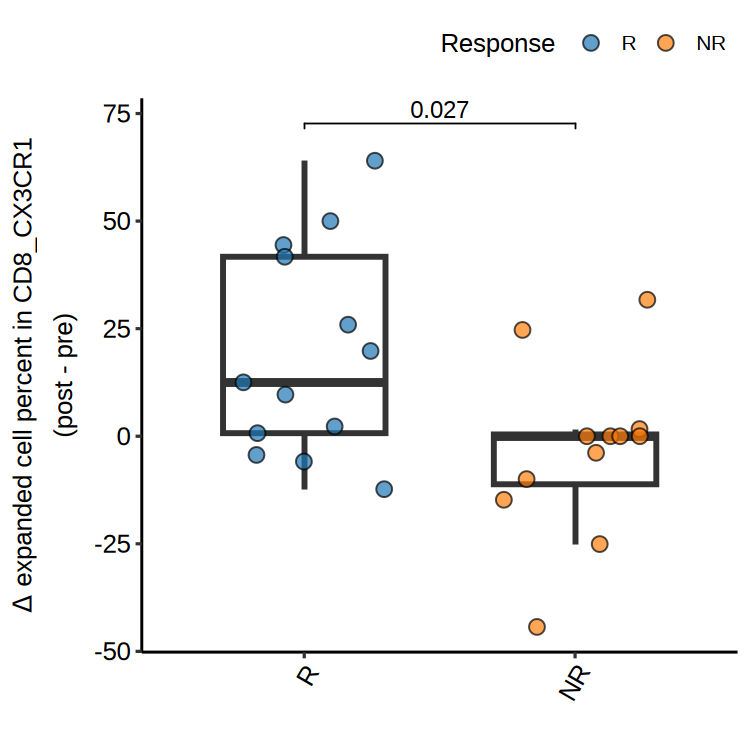

In [33]:

p <- read_tsv(f_expand_diff, show_col_types = F) %>% 
    filter(subtype == 'CD8_CX3CR1') %>%
    filter(!is.na(.data[[gp]])) %>% 
    cell_comp_boxplot(x = gp, y = 'pct_expand_diff', pt_fill = gp, pair_by = NULL, facet_by = NULL,
                      xorder = gp_lvls[[gp]], fill_order = gp_lvls[[gp]], xangle = 60)  +
    labs(y = bquote(atop(Delta~'expanded cell percent in CD8_CX3CR1', '(post - pre)')), fill = 'Response') +
    theme(legend.justification = c(1, 0))
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'pct_expand_diff',
    comparisons = gp_comp_diff_map[[gp]],
    apply_correction = FALSE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig5b-box_expand_diff-cx3cr1.pdf'), plot = p, width = 3, height = 4.5)
# 在当前 notebook 中显示最后生成的图。
p


### diversity: shannon index

In [34]:
# process
df <- read_csv(f_diversity, show_col_types = F) %>%
    filter(subtype == 'CD8_CX3CR1') %>%
    select(patient, sample_type, shannon) %>% 
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))

loginfo('%g samples for CD8_CX3CR1', nrow(df))
df %>% write_tsv(str_glue('{outdir}/fig5b-diversity-cd8_cx3cr1-min{min_cell_per_sample_subtype}.tsv'))

2026-07-17 22:49:38.667583 INFO::73 samples for CD8_CX3CR1


# A tibble: 1 × 13
  group1 group2 comparison_order paired    n1    n2 n_pairs statistic_W  p_raw
  <chr>  <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>  <dbl>
1 R-pre  R-post                1 FALSE     21    16      NA         237 0.0346
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


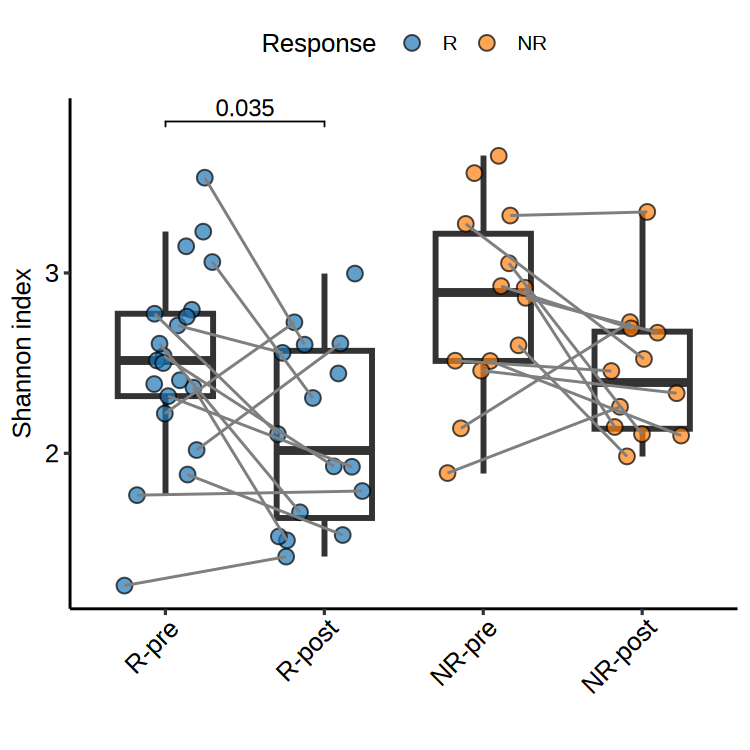

In [35]:
# Plot: compare pre versus post separately within R and NR.
fig5b_time_comparisons <- list(
    c('R-pre', 'R-post')
)

p <- read_tsv(
    str_glue('{outdir}/fig5b-diversity-cd8_cx3cr1-min{min_cell_per_sample_subtype}.tsv'),
    show_col_types = FALSE
) %>% 
    filter(!is.na(.data[[gp]])) %>% 
    cell_comp_boxplot(
        x = c(gp, 'sample_type'),
        y = 'shannon',
        pt_fill = gp,
        facet_by = NULL,
        xorder = comb_order,
        fill_order = gp_lvls[[gp]],
        xangle = 45
    ) +
    labs(y = 'Shannon index', fill = 'Response')

p <- configure_panel_wilcox(
    p,
    x = 'plot_x',
    y = 'shannon',
    comparisons = fig5b_time_comparisons,
    use_paired = FALSE,
    apply_correction = TRUE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)

ggsave(
    filename = str_glue('{outdir}/fig5b-box_diversity-cx3cr1.pdf'),
    plot = p,
    width = 3,
    height = 4.5
)
# 在当前 notebook 中显示最后生成的图。
p


## 5c: cyto/exhau score by A/B share/specific clones

- group cells by TCR sharing type: A/B-share/specific (A = CD8_CX3CR1)
- cyto/exhau summarise at cell level by TCR sharing type & sample & functional group

In [36]:
f_info <- '../data/Figure5/stage4/a05_clone_share/a_b_share_old/clone_cat_to_CD8_CX3CR1_per_cell.csv'
comp_ls <- list(
    c('A-specific', 'A-shared'),
    c('A-shared', 'B-shared'),
    c('B-specific', 'B-shared'),
    c('A-specific', 'B-shared')
)
group_order <- c('A-specific', 'A-shared', 'B-shared', 'B-specific')

In [37]:
# process
clone_info <- read_csv(f_info, show_col_types = F) %>% 
    filter(!grepl('^NK', compare_with))  # no NK cells
# rename cell types
for (nm in names(celltype_map)) {
    clone_info$subtype[clone_info$subtype %in% celltype_map[[nm]]] <- nm
    clone_info$compare_with[clone_info$compare_with %in% celltype_map[[nm]]] <- nm
}
# add cell state info
clone_info$cell_state <- 'unknown'
for (nm in names(cell_state_map)) {
    clone_info$cell_state[clone_info$compare_with %in% cell_state_map[[nm]]] <- nm
}
clone_info$cell_state[clone_info$cell_state == 'cytotoxic'] <- 'other cytotoxic'
loginfo('%g records', nrow(clone_info))

2026-07-17 22:49:44.337338 INFO::256399 records


In [38]:
# calculate median score & define as A/B-share/specific
df <- clone_info %>% 
    mutate(rep_ctype = if_else(subtype == 'CD8_CX3CR1', 'A', 'B')) %>% 
    unite(col = 'cell_group', rep_ctype, clone_cat2a, sep = '-', remove = F) %>% 
    summarise(.by = c('sample', 'patient', 'sample_type', 'cell_state', 'cell_group', 'clone_cat2a'),
              exhau_score = median(exhau),
              cyto_score = median(cyto)) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))
df %>% write_tsv(str_glue('{outdir}/fig5c-cyto_exhau_score-cell_state.tsv'))
loginfo('%g records after summrizing', nrow(df))

2026-07-17 22:49:44.648614 INFO::1183 records after summrizing


# A tibble: 16 × 14
   cell_state      group1     group2 comparison_order paired    n1    n2 n_pairs
   <fct>           <chr>      <chr>             <int> <lgl>  <int> <int>   <int>
 1 dying           A-specific A-sha…                1 FALSE     81    54      NA
 2 dying           A-shared   B-sha…                2 FALSE     54    51      NA
 3 dying           B-specific B-sha…                3 FALSE     81    51      NA
 4 dying           A-specific B-sha…                4 FALSE     81    51      NA
 5 exhausted       A-specific A-sha…                1 FALSE     81    68      NA
 6 exhausted       A-shared   B-sha…                2 FALSE     68    62      NA
 7 exhausted       B-specific B-sha…                3 FALSE     81    62      NA
 8 exhausted       A-specific B-sha…                4 FALSE     81    62      NA
 9 other cytotoxic A-specific A-sha…                1 FALSE     81    80      NA
10 other cytotoxic A-shared   B-sha…                2 FALSE     80    80      NA
11 other

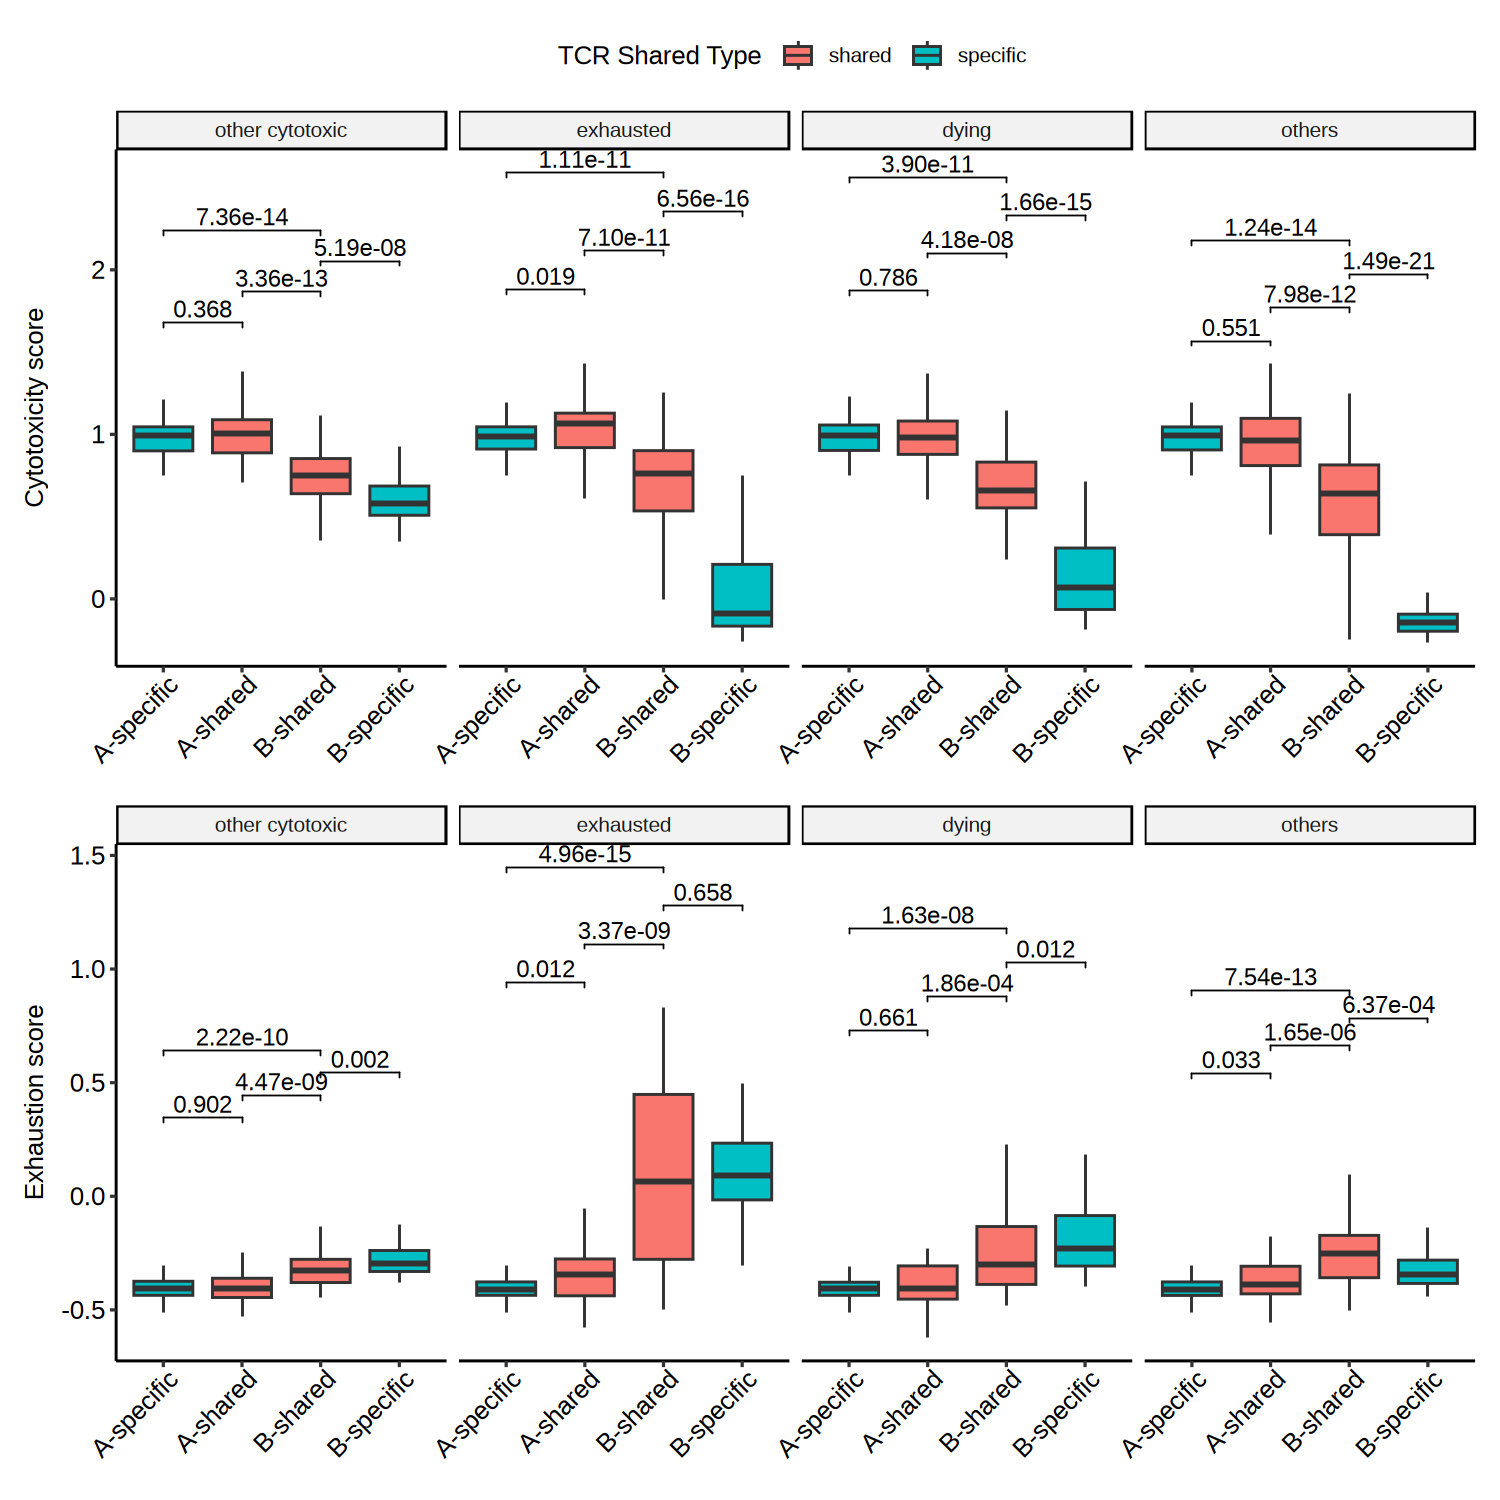

In [39]:

ylab_map <- list('cyto_score' = 'Cytotoxicity score', 'exhau_score' = 'Exhaustion score')
df <- read_tsv(str_glue('{outdir}/fig5c-cyto_exhau_score-cell_state.tsv'), show_col_types = FALSE) %>%
    mutate(
        cell_state = factor(cell_state, levels = c('other cytotoxic', 'exhausted', 'dying', 'others')),
        cell_group = factor(cell_group, levels = group_order)
    )
p_ls <- lapply(names(ylab_map), FUN = function(ycol) {
    p_i <- ggplot(data = df, aes(x = cell_group, y = .data[[ycol]])) +
        geom_boxplot(aes(fill = clone_cat2a), outlier.shape = NA) +
        facet_wrap(~ cell_state, nrow = 1) +
        labs(y = ylab_map[[ycol]], fill = 'TCR Shared Type') +
        theme(axis.text.x = element_text(angle = 45, hjust = .95), axis.title.x = element_blank())
    p_i <- configure_panel_wilcox(
        p_i,
        x = 'cell_group', y = ycol, comparisons = comp_ls, facet_by = 'cell_state',
        apply_correction = TRUE, correction_method = 'BH'
    )
    print(get_panel_wilcox_stats(p_i), n = Inf)
    p_i
})
p <- wrap_plots(p_ls, ncol = 1, guides = 'collect')
ggsave(
    filename = str_glue('{outdir}/fig5c-box_cyto_exhau_score-a_b_share.pdf'),
    plot = p, width = 14, height = 9
)

# 在当前 notebook 中显示组合图。
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 150)
p


## Export the final core resource data